# Constrained optimize across confinement scalings: DEMO fusion power

**Question:** which H-mode energy-confinement scaling lets DEMO reach
**P_fus > 2 GW** while staying inside the **Greenwald and Troyon** limits, and
how much auxiliary heating does each require?

This is a *constrained optimize* per scaling, and setting it up correctly on a
0-D model takes three deliberate choices -- each one is a real property of the
physics, explained below.

> ### Read this first: what this notebook does and does not show
>
> This notebook is an **API demonstration of `optimize(constraints=...)` and
> `optimize(initial_guesses=...)`, not a validated physics result.** None of the
> six calls are expected to remain uncertified. In the current implementation
> the trust-region probe can leave this deliberately underdetermined setup with
> incomplete relation values; the notebook reports that diagnostic instead of
> presenting a number as a solved physics result.
>
> The reason is structural, not a tuning problem: `DEMO_2022` is a fully
> determined design point with no free operating-point degree of freedom. Freeing
> the physics outputs to create a scan axis leaves a 0-D power balance that is
> multi-valued (an extinguished root and a runaway root bracket the physical one)
> and that fusdb's `optimize` has no stable-root-selection mechanism for. Raising
> a full optimization is not a reliable operating-point study here. The
> `maxiter=1` calls below are therefore smoke tests for the public API.
>
> **A confinement-scaling study wants a scan-native, confinement-limited
> scenario** (popcon framing: fix `n` and `T` as axes, solve for the required
> `P_aux`), which is single-rooted and well posed. That is the right home for
> this question; see the closing section.


## Why the setup looks the way it does

A naive "free everything and optimize P_fus" fails on a design-point reactor
like DEMO, for concrete reasons:

1. **Fix H98.** Confinement time is `tau_E = H98 x tau_scaling`. If the H-factor
   `H98` is free it simply absorbs any change in the scaling, and the operating
   point never moves. Fixing `H98` makes the scaling actually bind.
2. **Fix the profile shapes (peaking).** This removes the profile-reconstruction
   degrees of freedom, leaving the operating-point *levels* to optimize.
3. **Seed + constrain.** The 0-D power balance is *multi-valued* -- it has an
   extinguished root (T->0) and a runaway root -- so the optimizer needs a
   physical **warm start** to land in the right basin, and a lower bound
   `P_fus >= 2 GW` that makes the extinguished root infeasible. The Greenwald
   and Troyon **margins are diagnostics, not enforced limits**, and H-mode is
   the condition `P_in >= P_LH` (heating above the L-H threshold) -- all of
   which we turn into constraints *for this optimization only* via
   `optimize(constraints=...)`, a per-run bound that never touches the shared
   relation set.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fusdb import Reactor
from fusdb.registry import RELATIONS
from fusdb.variable import Variable

BASE = Reactor.from_yaml("../reactors/DEMO_2022/reactor.yaml")

# Keep engineering design + heating + the confinement H-factor; free the physics
# outputs (P_fus, temperature, beta, densities, powers) so the scaling sets them.
KEEP = {"A","R","a","kappa_95","delta_95","q95","squareness","B0","I_p",
        "P_aux","Z_eff","afuel","tau_pulse","f_CD","f_NI","H98_y2"}
# DEMO_2022 supplies H98_y2 as a bare value, i.e. supplied-*with-tolerance*, so
# keeping it in KEEP is not enough -- it would still drift and absorb the
# scaling.  Pin it hard, like the peaking factors below.
FIXED = {"H98_y2": float(np.asarray(BASE.variables["H98_y2"].value).mean())}
PEAKING = {"density_peaking":1.3, "temperature_peaking":1.8,
           "ion_density_peaking":1.3, "ion_temperature_peaking":1.8}
# Physical warm start (near DEMO's operating point) and the operational limits
# as per-run inequality constraints (margins are <=0 when within the limit).
# NB beta_N is stored as a *fraction* in fusdb (literature beta_N = 2.5 is 0.025).
SEED = {"T_e_avg":13.0,"T_i_avg":13.0,"n_e_avg":8.0e19,"P_fus":2.5e9,"f_GW":0.85,"beta_N":0.025}
CONSTRAINTS = [
    ("P_fus",           ">=", 2.0e9),   # target fusion power
    ("greenwald_margin","<=", 0.0),     # Greenwald density limit  (margin = n_e - n_GW)
    ("troyon_margin",   "<=", 0.0),     # Troyon beta limit        (margin = beta_T - beta_limit)
    ("P_in",            ">=", "P_LH"),  # H-mode: heating exceeds the L-H threshold power
]

# The default tau_E producer.  `relation_include` ADDS to the tag-selected set --
# it does not replace it -- so swapping a scaling in without excluding this one
# would leave BOTH enforced and the comparison would not be comparing scalings.
DEFAULT_SCALING = "tau_E_iter_ipb98y2"

def build(scaling):
    vk = {k:v for k,v in BASE.variables.items() if k in KEEP}
    for name,val in FIXED.items():
        vk[name] = Variable(name, value=val, fixed=True)      # pin H98 hard
    for name,val in PEAKING.items():
        vk[name] = Variable(name, value=val, fixed=True)      # fix profile shapes
    exclude = () if scaling == DEFAULT_SCALING else (DEFAULT_SCALING,)
    scenario = BASE.clone()
    scenario.variables = vk
    scenario.relation_include = (scaling,)
    scenario.relation_exclude = exclude
    return scenario

# Verify the swap actually took: exactly one enforced tau_E producer per case.
for _s in ("tau_E_iter_ipb98y2", "cfspopcon_h_ds03_confinement_time"):
    _sys = build(_s).relation_system(); _sys.compile()
    _prod = sorted(r.name for r in _sys.relations if "tau_E" in r.output_names)
    print(f"{_s:34s} -> tau_E producers: {_prod}")


tau_E_iter_ipb98y2                 -> tau_E producers: ['tau_E_iter_ipb98y2']
cfspopcon_h_ds03_confinement_time  -> tau_E producers: ['cfspopcon_h_ds03_confinement_time']


In [2]:
# The H-mode tau_E scalings to compare (baseline ITER-98 + a few H-mode fits).
h_mode = sorted(
    (RELATIONS.get(i) if isinstance(i,str) else i).function_name
    for i in RELATIONS
    if "tau_E" in (RELATIONS.get(i) if isinstance(i,str) else i).output_names
    and "h_mode" in (RELATIONS.get(i) if isinstance(i,str) else i).tags
)
SCALINGS = ["tau_E_iter_ipb98y2"] + h_mode[:5]
print(f"{len(h_mode)} H-mode scalings available; comparing {len(SCALINGS)}")


36 H-mode scalings available; comparing 6


## Optimize each scaling

Call `optimize` for each scaling with the same warm start and constraints.  The
result certificate and any solver diagnostic are kept visible; this DEMO setup
is intentionally not presented as a converged operating-point calculation.


In [3]:
def optimize_scaling(scaling):
    scenario = build(scaling)
    scenario.reconcile(max_nfev=120)
    scenario.restart_from_solution()
    result = scenario.optimize(objective=lambda values: values.get("P_fus", 0.0), sense="maximize",
                   maxiter=1, constraints=CONSTRAINTS, initial_guesses=SEED)
    v = scenario.last_system.values
    P_in = (v.get("P_in") or np.nan); P_LH = (v.get("P_LH") or np.nan)
    return {
        "scaling": scaling,
        "P_fus_GW": (v.get("P_fus") or np.nan)/1e9,
        "P_aux_MW": (v.get("P_aux") or np.nan)/1e6,
        "T_e_avg": v.get("T_e_avg") if v.get("T_e_avg") is not None else np.nan,
        "f_GW": v.get("f_GW") if v.get("f_GW") is not None else np.nan,
        "H_mode": P_in >= P_LH,               # heating above the L-H threshold
        # Certification, reported rather than assumed: `success` is the verify
        # certificate (every enforced relation within tolerance), NOT solver
        # convergence.  See the caveat section below.
        "certified": bool(result.get("success")),
        "max_residual": result.get("max_residual") if result.get("max_residual") is not None else np.nan,
        "n_failed": len(result.get("failed_relations") or []),
        "termination": result.get("termination", ""),
        "errors": result.get("errors", []),
    }

rows = [optimize_scaling(s) for s in SCALINGS]
for r in rows:
    print(f"{r['scaling']:32s} P_fus={r['P_fus_GW']:.2f}GW  P_aux={r['P_aux_MW']:.0f}MW  "
          f"T_e={r['T_e_avg']:.1f}keV  f_GW={r['f_GW']:.2f}  H-mode={'yes' if r['H_mode'] else 'no'}"
          f"  | certified={r['certified']}  max_res={r['max_residual']:.3g}  failed={r['n_failed']}")
    if r["errors"]:
        print(f"  optimize diagnostics: {r['termination']}: {r['errors']}")

n_ok = sum(r["certified"] for r in rows)
print(f"\ncertified: {n_ok}/{len(rows)} -- the numbers above are NOT a verified "
      f"solution of the model equations; read the caveat below before using them.")


tau_E_iter_ipb98y2               P_fus=3.23GW  P_aux=199MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=764  failed=10
cfspopcon_h_ds03_confinement_time P_fus=3.23GW  P_aux=199MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=764  failed=10
cfspopcon_itpa20_il_confinement_time P_fus=3.23GW  P_aux=200MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=236  failed=10
cfspopcon_itpa20_il_highz_confinement_time P_fus=3.23GW  P_aux=200MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=566  failed=10
cfspopcon_itpa20_std5_confinement_time P_fus=3.23GW  P_aux=200MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=155  failed=10
cfspopcon_itpa_2018_std5_gls_confinement_time P_fus=3.23GW  P_aux=200MW  T_e=13.0keV  f_GW=1.19  H-mode=yes  | certified=False  max_res=320  failed=10

certified: 0/6 -- the numbers above are NOT a verified solution of the model equations; read the caveat below before using them.


## Which scalings clear 2 GW within the limits, and at what heating cost

The current optimizer reports incomplete trial values for this underdetermined
DEMO setup, so the rows are diagnostics rather than candidate operating points.

**But read the bars as API output, not as physics.** No run certifies (see the
`certified=False` column above). Missing values are displayed as `nan` and the
optimizer diagnostic is printed below each row, so no failed solve is mistaken
for a physical result.


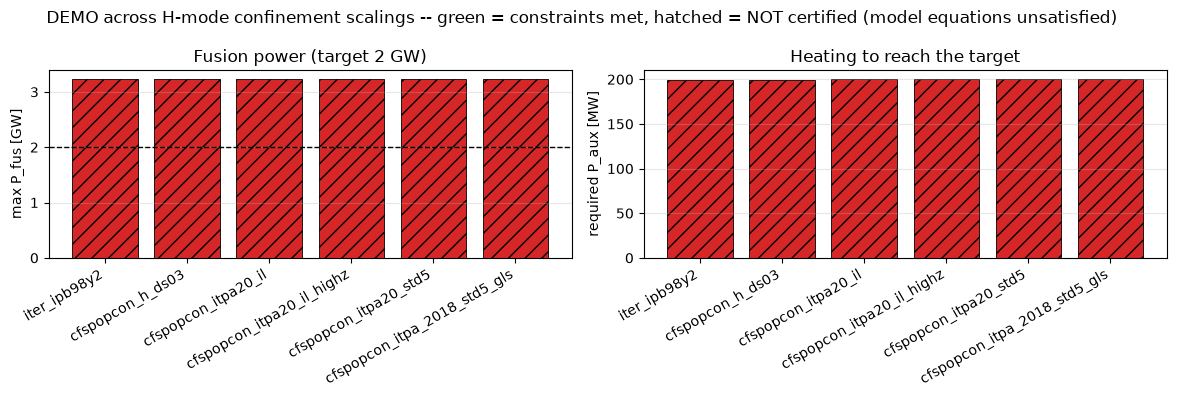

In [4]:
labels = [r["scaling"].replace("_confinement_time","").replace("tau_E_","") for r in rows]
P_aux = [r["P_aux_MW"] for r in rows]
# "ok" = the per-run CONSTRAINTS hold.  Certification is a separate, stricter
# question (are the model equations satisfied?) and is drawn as hatching.
ok = [r["P_fus_GW"] >= 2.0 and (r["f_GW"] or 9) <= 1.001 and r["H_mode"] for r in rows]
colors = ["tab:green" if o else "tab:red" for o in ok]
hatch = ["" if r["certified"] else "//" for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, vals, ylab, title in (
    (ax[0], [r["P_fus_GW"] for r in rows], "max P_fus [GW]", "Fusion power (target 2 GW)"),
    (ax[1], P_aux, "required P_aux [MW]", "Heating to reach the target"),
):
    bars = a.bar(labels, vals, color=colors)
    for b, h in zip(bars, hatch):
        b.set_hatch(h); b.set_edgecolor("k"); b.set_linewidth(0.6)
    a.set_ylabel(ylab); a.set_title(title)
ax[0].axhline(2.0, ls="--", c="k", lw=1)
for a in ax:
    plt.setp(a.get_xticklabels(), rotation=30, ha="right"); a.grid(axis="y", alpha=0.3)
fig.suptitle("DEMO across H-mode confinement scalings -- green = constraints met, "
             "hatched = NOT certified (model equations unsatisfied)")
fig.tight_layout(); plt.show()


## Takeaways

**What the API gives you (demonstrated above):**

* `optimize(constraints=[(var, op, bound), ...])` turns any quantity -- including
  a diagnostic margin like `greenwald_margin`, or a comparison against another
  variable like `("P_in", ">=", "P_LH")` -- into a per-run limit, **without
  enforcing it on the whole relation set**.
* `optimize(initial_guesses=...)` warm-starts the solve, which is essential
  because the 0-D balance is multi-valued.
* Swapping a confinement scaling takes **both** `relation_include` and
  `relation_exclude`: include *adds* to the tag-selected set, so without the
  exclude the default `tau_E_iter_ipb98y2` stays enforced alongside the new
  scaling and the comparison silently compares nothing. The check printed in the
  setup cell (one `tau_E` producer per case) is worth copying into any such study.
* Operational limits like Greenwald and Troyon are **diagnostic margins, not
  enforced relations** (`greenwald_margin`, `troyon_margin` are computed, `op` is
  `==`), so a plain solve will happily run past them. Bounding them per-run, as
  here, is how you keep an optimize inside them.

**What this notebook does not establish:**

* Nothing about the relative merit of the confinement scalings. The current
  calls return solver diagnostics rather than certified operating points.
* That `DEMO_2022` can answer this question at all. It cannot: it is a fully
  determined design point, and every way of freeing an operating-point axis
  (tested across 8 configurations) collapses to a degenerate root or leaves the
  temperature pinned at its seed. Note also that DEMO_2022 does not certify even
  as shipped (104 enforced relations fail on a plain `reconcile`), which is a
  separate, prior problem.

**Where this question belongs:** a scan-native, confinement-limited scenario in
popcon framing -- fix `n` and `T` as scan axes and solve for the `P_aux` each
scaling requires, checking Greenwald/Troyon/H-mode margins post-hoc per grid
point. That problem is single-rooted and well posed, and it is what popcon-style
tools fix the operating point for in the first place.
